Goals: 
1) Build a base model which extracts features at two separate layers (earlier and later layers respectively) and performs,
K-means (MiniBatch) clustering on each of those embeddings to get genus and species level clusters from the dataset. 

In [1]:
# Import Statements
import torch
import torch.nn as nn
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import os
from PIL import Image
from torch.utils.data import DataLoader, SubsetRandomSampler
from torchvision import datasets, models, transforms
from torch.utils.data import Dataset
from sklearn.cluster import KMeans, MiniBatchKMeans
from sklearn.preprocessing import normalize
from sklearn.metrics import silhouette_score
import umap
import shutil
import random
from tqdm import tqdm
import warnings
import glob
import seaborn as sns
import plotly.express as px
from pathlib import Path
from collections import defaultdict

In [15]:
print(torch.cuda.is_available())

True


In [16]:
# Check gpu useage

print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
print("CUDA device count:", torch.cuda.device_count())
print("Current device:", torch.cuda.current_device())
print("Device name:", torch.cuda.get_device_name(torch.cuda.current_device()))

print(torch.version.cuda)          # PyTorch CUDA version
print(torch.backends.cudnn.enabled) # Should be true

PyTorch version: 2.8.0+cu129
CUDA available: True
CUDA device count: 1
Current device: 0
Device name: NVIDIA GeForce RTX 4050 Laptop GPU
12.9
True


In [17]:
# GPU useage test
import torch
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

x = torch.randn(1000, 1000, device=device)
y = torch.mm(x, x)
print(y.device) 

Device: cuda
cuda:0


In [18]:
# Paths to image and metadata subset

subset_img_dir = "[YOUR IMG PATH HERE]"    
subset_csv_path = "[YOUR METADATA CSV PATH HERE]"        

seed = 42
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)


# Device setup
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Load metadata

df_meta = pd.read_csv(subset_csv_path)
assert 'hash_id' in df_meta.columns, "CSV missing 'hash_id' column"
assert 'family' in df_meta.columns, "CSV missing 'family' column"

df_meta.rename(columns={'family': 'family_cluster'}, inplace=True)
print("Metadata preview:")
print(df_meta.head())

# Map images to csv filepaths
image_dir = Path(subset_img_dir)
allowed_exts = {'.jpg', '.jpeg', '.png'}

# 1) Index all images once (recursive: look into all directories and sub-directories)
all_paths = [p for p in image_dir.rglob("*") if p.suffix.lower() in allowed_exts]
print(f"Indexed {len(all_paths):,} image files")

# 2) Build stem to list(paths) mapping
# Defaultdict(list) creates an empty list for new keys and '.append' adds the object 'p' as a string in that list for every path in our list 'all_paths'
stem_to_paths = defaultdict(list) 
for p in all_paths:
    stem_to_paths[p.stem].append(str(p))

# 3) Create a simple first-match dict (stem to first path)
first_match = {stem: paths[0] for stem, paths in stem_to_paths.items()}

# 4) Vectorized mapping into dataframe (fast)
df_meta['hash_id_str'] = df_meta['hash_id'].astype(str).str.strip()
df_meta['path'] = df_meta['hash_id_str'].map(first_match)  # NaN for missing

# 5) Build the same dict you had originally
df_meta_found = df_meta[df_meta['path'].notna()].reset_index(drop=True)
hashid_to_path = dict(zip(df_meta_found['hash_id_str'], df_meta_found['path']))
missing_hashids = df_meta[df_meta['path'].isna()]['hash_id_str'].tolist()

print(f"Found {len(hashid_to_path):,} matches; {len(missing_hashids):,} missing.")
if missing_hashids:
    print("Example missing ids:", missing_hashids[:5])

Using device: cuda
Metadata preview:
                    hash_id family_cluster
0  223m6ywujk3htx2s3kfqx7ee    Acanthaceae
1  2aba7w224g4tso44mtzpnizg    Acanthaceae
2  2dovrj4uex7apou4zyu7nau7    Acanthaceae
3  2f53p6wsfhsnik2sy3jxn2ok    Acanthaceae
4  2fvqsa7ldatavhuevcvia5lm    Acanthaceae
Indexed 49,633 image files
Found 49,633 matches; 0 missing.


In [19]:
# Dataset and dataloader
# Image transforms
img_transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

# Dataset
class HashImageDataset(Dataset):
    def __init__(self, mapping, transform=None):
        self.items = list(mapping.items())
        self.transform = transform

    def __len__(self):
        return len(self.items)

    def __getitem__(self, idx):
        hid, path = self.items[idx]
        with Image.open(path) as img:
            img = img.convert('RGB')
            if self.transform:
                img = self.transform(img)
        return hid, img

dataset = HashImageDataset(hashid_to_path, img_transform)
loader = DataLoader(dataset, batch_size=64, shuffle=False, num_workers=0, pin_memory=True)

In [20]:
# Model

class ResNet50Intermediate(nn.Module):
    def __init__(self):
        super().__init__()
        base = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V1)
        self.conv1 = base.conv1
        self.bn1 = base.bn1
        self.relu = base.relu
        self.maxpool = base.maxpool
        self.layer1 = base.layer1
        self.layer2 = base.layer2
        self.layer3 = base.layer3
        self.layer4 = base.layer4
        self.avgpool = base.avgpool
        self.layer3_pool = nn.AdaptiveAvgPool2d((1, 1))
        for p in self.parameters():
            p.requires_grad = False
        self.eval()

    def forward(self, x):
        x = self.conv1(x)
        x = self.bn1(x)
        x = self.relu(x)
        x = self.maxpool(x)
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        g = self.layer3_pool(x).flatten(1)
        x = self.layer4(x)
        s = self.avgpool(x).flatten(1)
        return g, s

model = ResNet50Intermediate().to(device).eval()

In [21]:
# Extract embeddings

genus_embeds, species_embeds, hash_order = [], [], []

with torch.no_grad():
    for hids, imgs in tqdm(loader, desc="Extracting embeddings"):
        imgs = imgs.to(device, non_blocking=True)
        
        g, s = model(imgs)

        # Move embeddings to cpu for storage
        genus_embeds.append(g.cpu().numpy())
        species_embeds.append(s.cpu().numpy())
        hash_order.extend(hids)

genus_embeds = np.vstack(genus_embeds)
species_embeds = np.vstack(species_embeds)

print("Genus embeddings shape:", genus_embeds.shape)
print("Species embeddings shape:", species_embeds.shape)
print("GPU memory used:", torch.cuda.memory_allocated(device)/1024**2, "MB")

Extracting embeddings: 100%|██████████| 776/776 [12:46<00:00,  1.01it/s]


Genus embeddings shape: (49633, 1024)
Species embeddings shape: (49633, 2048)
GPU memory used: 126.1826171875 MB


In [22]:
# UMAP dimensionality reducation

umap_genus = umap.UMAP(n_neighbors=40, n_components=64, min_dist=0.2, random_state=seed)
umap_species = umap.UMAP(n_neighbors=30, n_components=128, min_dist=0.05, random_state=seed)

genus_reduced = umap_genus.fit_transform(genus_embeds)
species_reduced = umap_species.fit_transform(species_embeds)

C:\Users\mlasz\anaconda3\envs\biotrove\lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
C:\Users\mlasz\anaconda3\envs\biotrove\lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


In [23]:
#Minibatch KMeans clustering

kmeans_genus = MiniBatchKMeans(n_clusters=895, random_state=seed, batch_size=128)
kmeans_species = MiniBatchKMeans(n_clusters=537, random_state=seed, batch_size=128)

genus_labels = kmeans_genus.fit_predict(genus_reduced)
species_labels = kmeans_species.fit_predict(species_reduced)

C:\Users\mlasz\anaconda3\envs\biotrove\lib\site-packages\sklearn\cluster\_kmeans.py:1952: UserWarning: MiniBatchKMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can prevent it by setting batch_size >= 3584 or by setting the environment variable OMP_NUM_THREADS=1
  warnings.warn(
C:\Users\mlasz\anaconda3\envs\biotrove\lib\site-packages\sklearn\cluster\_kmeans.py:1952: UserWarning: MiniBatchKMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can prevent it by setting batch_size >= 3584 or by setting the environment variable OMP_NUM_THREADS=1
  warnings.warn(


In [24]:
# Build result dataframe

df_out = pd.DataFrame({
    'hash_id': hash_order,
    'genus_cluster': genus_labels,
    'species_cluster': species_labels
})

df_meta_found['hash_id'] = df_meta_found['hash_id'].astype(str)
df_result = pd.merge(df_meta_found, df_out, on='hash_id', how='inner')
df_result = df_result[['hash_id', 'family_cluster', 'genus_cluster', 'species_cluster']]

df_result.head(n=50)

,hash_id,family_cluster,genus_cluster,species_cluster
0,223m6ywujk3htx2s3kfqx7ee,Acanthaceae,53,509
1,2aba7w224g4tso44mtzpnizg,Acanthaceae,790,512
2,2dovrj4uex7apou4zyu7nau7,Acanthaceae,318,286
3,2f53p6wsfhsnik2sy3jxn2ok,Acanthaceae,179,181
4,2fvqsa7ldatavhuevcvia5lm,Acanthaceae,781,242
5,2hfnnbd3jynefj7wwrjmoiom,Acanthaceae,121,53
6,2io2zgcmes2cyb7sqsretfaf,Acanthaceae,132,443
7,2rqd2pcfkbx5fjgxeqekrqpd,Acanthaceae,317,276
8,2sk3qrjopdttzt4kfr2xnsm4,Acanthaceae,467,494
9,32lag3mk53wdetwxidt2j7se,Acanthaceae,450,94


In [29]:
df_result.to_csv("YOUR RESULT CSV PATH HERE", index=False)

In [30]:
# Optional: Save embeddings

embed_dir = os.path.join(os.path.dirname(subset_csv_path), "embeddings")
os.makedirs(embed_dir, exist_ok=True)

np.save(os.path.join(embed_dir, "genus_embeddings.npy"), genus_embeds)
np.save(os.path.join(embed_dir, "species_embeddings.npy"), species_embeds)
print("Embeddings saved to", embed_dir)

Embeddings saved to C:/Users/mlasz/OneDrive/Desktop/mlm_25/biotrove_data/biotrove-clustering_unzipped\embeddings


C:\Users\mlasz\anaconda3\envs\biotrove\lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


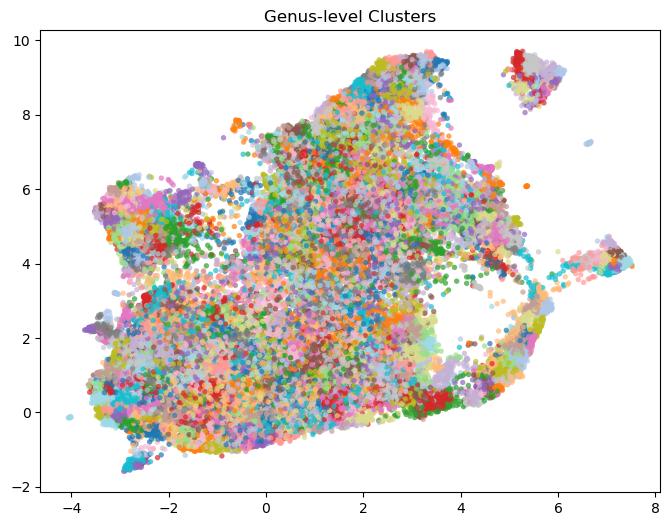

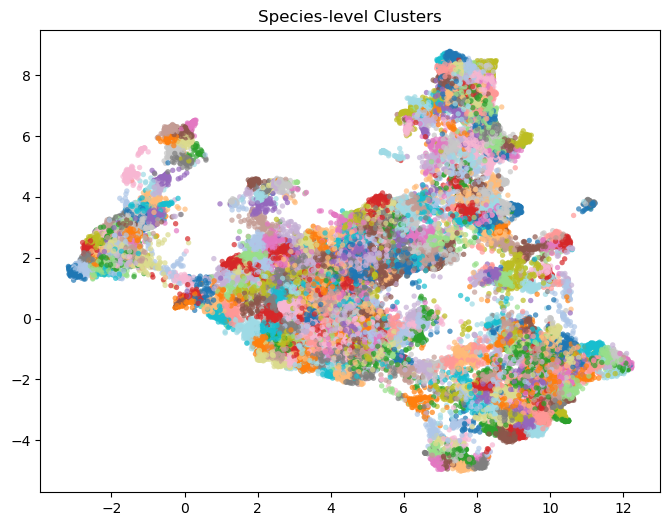

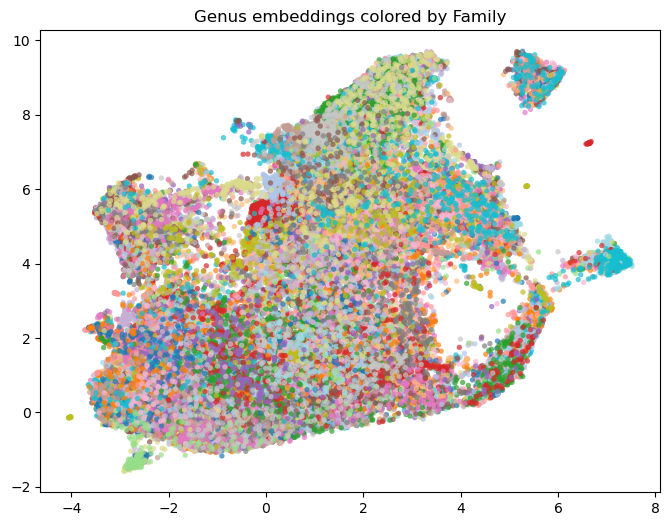

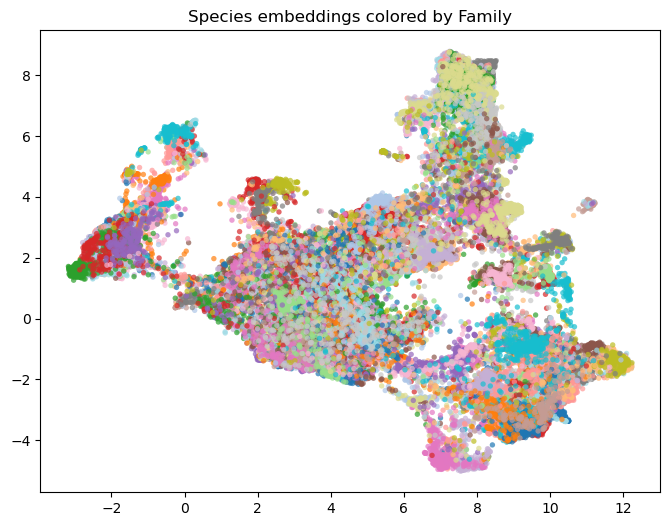

In [32]:
# Reduce dimensions and plot
# Reduce to 2D for plotting
umap_2d = umap.UMAP(n_neighbors=15, n_components=2, min_dist=0.1, random_state=seed)
genus_2d = umap_2d.fit_transform(genus_embeds)
species_2d = umap_2d.fit_transform(species_embeds)

# Plot function
def plot_umap(coords, labels, title):
    plt.figure(figsize=(8,6))
    sns.scatterplot(x=coords[:,0], y=coords[:,1], hue=labels, s=15, linewidth=0, alpha=0.7, palette="tab20")
    plt.title(title)
    plt.legend([],[], frameon=False)
    plt.show()

# Visualize genus clusters
plot_umap(genus_2d, genus_labels, "Genus-level Clusters")

# Visualize species clusters
plot_umap(species_2d, species_labels, "Species-level Clusters")

# Optionally color by family
plot_umap(genus_2d, df_result['family_cluster'], "Genus embeddings colored by Family")
plot_umap(species_2d, df_result['family_cluster'], "Species embeddings colored by Family")